In [ ]:
#1. IMPORT LIBRARIES & SETUP
  
from dotenv import load_dotenv    #to load .env file
import os                         #interact with Operating System
from google.cloud import bigquery #connect to BigQuery

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from scipy import stats

In [24]:
# 2. CONNECT TO BIGQUERY
load_dotenv()   #load file .env with google cloud project id

PROJECT_ID = os.getenv('PROJECT_ID')
print(f"Project ID {'[HIDDEN FOR SECURITY] - Loaded successfully' if PROJECT_ID else 'NONE FOUND (create .env file with PROJECT_ID)'}")

client = bigquery.Client(project=PROJECT_ID)
print("Connected to BigQuery successfully!")

Project ID [HIDDEN FOR SECURITY] - Loaded successfully
Connected to BigQuery successfully!


In [25]:
# 3. DATA SELECTION  (JOINS)
query = { "orders_products": 
    """ SELECT
    o.order_id,         #124790 righe
    o.user_id,
    o.status AS order_status,
    o.gender,
    o.created_at AS order_created_at,
    o.shipped_at AS order_shipped_at,
    o.num_of_item,

    oi.id AS order_item_id,          
    oi.sale_price,
    oi.status AS item_status,

    p.id AS product_id,           
    p.name AS product_name,
    p.category,
    p.brand,
    p.cost,
    p.retail_price,
    p.department,
    p.distribution_center_id

FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
    ON oi.order_id = o.order_id
JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
    ON oi.product_id = p.id
WHERE o.created_at <= CURRENT_TIMESTAMP() 
    AND (o.shipped_at <= CURRENT_TIMESTAMP() OR o.shipped_at IS NULL) """}

In [26]:
# 4. LOAD GLOBAL TABLE ORDERS AND PRODUCT JOIN
try:
    orders_products_df = client.query(query["orders_products"]).to_dataframe()
    print(orders_products_df.info())
    
except Exception as e:
    print(f"Something went wrong: {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179009 entries, 0 to 179008
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   order_id                179009 non-null  Int64              
 1   user_id                 179009 non-null  Int64              
 2   order_status            179009 non-null  object             
 3   gender                  179009 non-null  object             
 4   order_created_at        179009 non-null  datetime64[us, UTC]
 5   order_shipped_at        115788 non-null  datetime64[us, UTC]
 6   num_of_item             179009 non-null  Int64              
 7   order_item_id           179009 non-null  Int64              
 8   sale_price              179009 non-null  float64            
 9   item_status             179009 non-null  object             
 10  product_id              179009 non-null  Int64              
 11  product_name            17

In [27]:
# 4.1 CHECKING DATA QUALITY FROM JOIN
query_rows = { "check_rows": 
    """SELECT 
    COUNT(*) as total_rows,
    COUNT(DISTINCT oi.order_id) as orders_count,
    COUNT(DISTINCT oi.product_id) as unique_products
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o ON oi.order_id = o.order_id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` AS p ON oi.product_id = p.id"""}

try:
    check_rows = client.query(query_rows["check_rows"]).to_dataframe()
    print(check_rows.head())
    
except Exception as e:
    print(f"Something went wrong: {e}")

   total_rows  orders_count  unique_products
0      180539        124505            29052


In [28]:
query_check = { "missing_rows": 
    """SELECT 
    oi.order_id,
    o.order_id AS check_order_id,
    o.created_at,
    o.shipped_at
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o ON oi.order_id = o.order_id
WHERE o.order_id IS NULL  -- Identify missing order records
   OR (o.created_at > CURRENT_TIMESTAMP()) -- Identify orders with future timestamps
   OR (o.shipped_at > CURRENT_TIMESTAMP()) -- Identify shipments with future timestamps"""}

try:
    missing_rows_df = client.query(query_check["missing_rows"]).to_dataframe()
    print(missing_rows_df.info())
    
except Exception as e:
    print(f"Something went wrong: {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   order_id        1530 non-null   Int64              
 1   check_order_id  1530 non-null   Int64              
 2   created_at      1530 non-null   datetime64[us, UTC]
 3   shipped_at      1530 non-null   datetime64[us, UTC]
dtypes: Int64(2), datetime64[us, UTC](2)
memory usage: 50.9 KB
None


In [29]:
total_original = check_rows["total_rows"].iloc[0]
processed_count = len(orders_products_df)
excluded_count = len(missing_rows)

print("--- DATA QUALITY CHECK SUMMARY ---")
print(f"Total rows in 'order_items': {total_original}")
print(f"Processed rows (after JOIN & Filters): {processed_count}")
print(f"Excluded records: {excluded_count}")
print("\nAnalysis of excluded records:")
print(f"The {excluded_count} excluded rows represent data inconsistencies identified by the 'missing_rows' check.")
print("These fall into two categories:")
print("1. Orphaned records: Items in order_items that lack a corresponding entry in the orders table.")
print("2. Anomalies: Orders with future timestamps, likely representing synthetic test data.")
print(f"\nBy applying the filters in our main query, we ensure that our final dataset of {processed_count} entries")
print("is clean, reliable, and based only on valid, completed transaction data.")
print("Note: This is a synthetic, live-updating dataset; minor variations in row counts are expected.")

--- DATA QUALITY CHECK SUMMARY ---
Total rows in 'order_items': 180539
Processed rows (after JOIN & Filters): 179009
Excluded records: 1633

Analysis of excluded records:
The 1633 excluded rows represent data inconsistencies identified by the 'missing_rows' check.
These fall into two categories:
1. Orphaned records: Items in order_items that lack a corresponding entry in the orders table.
2. Anomalies: Orders with future timestamps, likely representing synthetic test data.

By applying the filters in our main query, we ensure that our final dataset of 179009 entries
is clean, reliable, and based only on valid, completed transaction data.
Note: This is a synthetic, live-updating dataset; minor variations in row counts are expected.


In [30]:
# APPLY LOWERCASE TO ALL OBJECT COLUMNS

orders_products_df[orders_products_df.select_dtypes(include=["object"]).columns] = \
    orders_products_df.select_dtypes(include=["object"]).apply(lambda x: x.str.lower().str.strip())

print("Text standardization completed.")

Text standardization completed.


--- EXECUTIVE SUMMARY (KPIs) ---
 Total Revenue: $10,666,954.70
 Total Cost: $5,129,761.82
 Total Profit: $5,537,192.88
 Avg Profit Margin: 51.05%
 Total Orders: 123,441
 Unique Customers: 79,230
 Average Order Value (AOV): $86.41


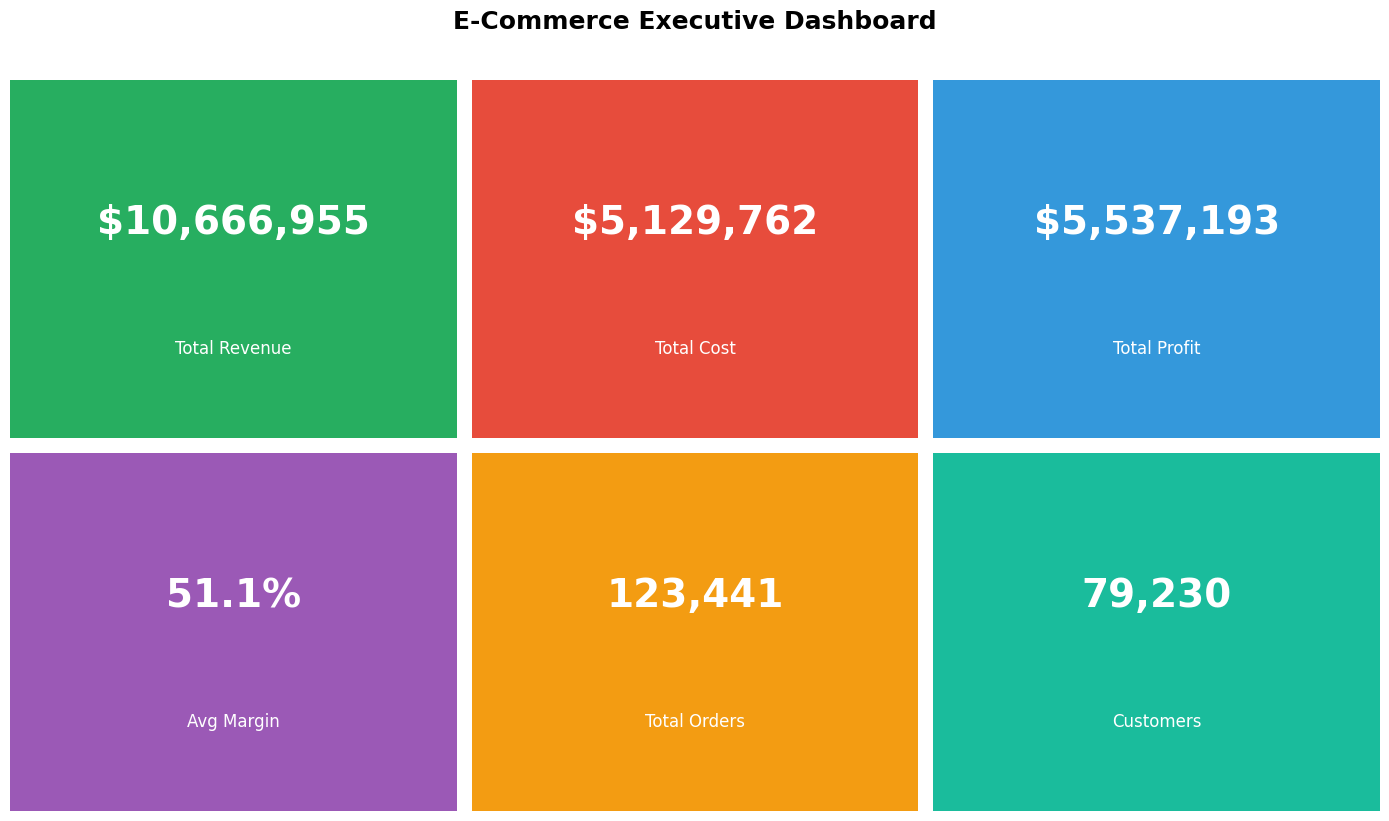



Average Order Value (AOV) gives us the mathematical mean,
the distribution reveals actual customer behavior. It tells us if our
revenue is driven by many small purchases or a few high-value 'whales'.
The Standard Deviation (std) shows how widely customer spending varies.


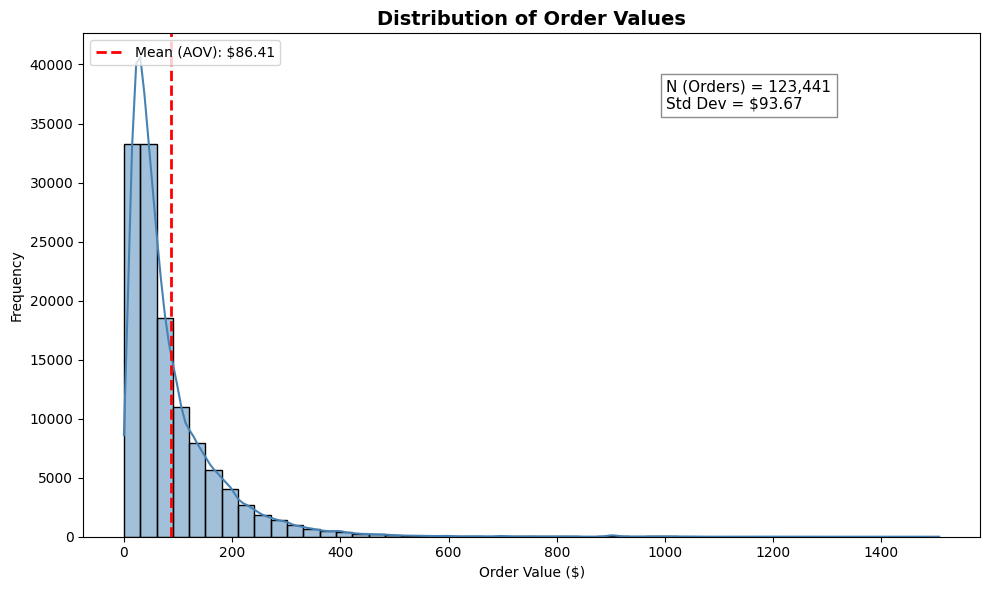

In [ ]:
# --- 5. FEATURE ENGINEERING: Creating Key Metrics ---

#Create new calculated columns
orders_products_df["profit"] = orders_products_df["sale_price"] - orders_products_df["cost"]
orders_products_df["profit_margin"] = (orders_products_df["profit"] / orders_products_df["sale_price"]) * 100

#Calculate KPIs
total_revenue = orders_products_df["sale_price"].sum()
total_cost = orders_products_df["cost"].sum()
total_profit = orders_products_df["profit"].sum()
avg_profit_margin = orders_products_df["profit_margin"].mean()
total_orders = orders_products_df["order_id"].nunique()
total_customers = orders_products_df["user_id"].nunique()

# Calculate AOV, N, and Standard Deviation
order_totals = orders_products_df.groupby("order_id")["sale_price"].sum().reset_index()
order_totals.columns = ["order_id", "order_value"]

aov = order_totals["order_value"].mean()
std_dev = order_totals["order_value"].std() 
n_total = len(order_totals) 

# Executive Summary
print("--- EXECUTIVE SUMMARY (KPIs) ---")
print(f" Total Revenue: ${total_revenue:,.2f}")
print(f" Total Cost: ${total_cost:,.2f}")
print(f" Total Profit: ${total_profit:,.2f}")
print(f" Avg Profit Margin: {avg_profit_margin:.2f}%")
print(f" Total Orders: {total_orders:,}")
print(f" Unique Customers: {total_customers:,}")
print(f" Average Order Value (AOV): ${aov:.2f}")   

# --- PLOTTING EXECUTIVE SUMMARY  ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("E-Commerce Executive Dashboard", fontsize=18, fontweight="bold", y=1.02)

# KPI Data
kpis = [
    ("Total Revenue", f"${total_revenue:,.0f}", "#27ae60"),
    ("Total Cost", f"${total_cost:,.0f}", "#e74c3c"),
    ("Total Profit", f"${total_profit:,.0f}", "#3498db"),
    ("Avg Margin", f"{avg_profit_margin:.1f}%", "#9b59b6"),
    ("Total Orders", f"{total_orders:,}", "#f39c12"),
    ("Customers", f"{total_customers:,}", "#1abc9c")
]

for ax, (title, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha="center", va="center", fontsize=28, fontweight="bold", color="white", transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha="center", va="center", fontsize=12, color="white", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

# --- BUSINESS CONTEXT  ---
print("\n")
print("Average Order Value (AOV) gives us the mathematical mean,")
print("the distribution reveals actual customer behavior. It tells us if our")
print("revenue is driven by many small purchases or a few high-value 'whales'.")
print("The Standard Deviation (std) shows how widely customer spending varies.")


# Plotting the Distribution
plt.figure(figsize=(10, 6))
sns.histplot(order_totals["order_value"], bins=50, kde=True, color="steelblue")

# Add Mean Line
plt.axvline(aov, color="red", linestyle="--", linewidth=2, label=f"Mean (AOV): ${aov:.2f}")

# Add Statistical Text Box (N and Std)
stats_text = f"N (Orders) = {n_total:,}\nStd Dev = ${std_dev:.2f}"
plt.gca().text(0.65, 0.85, stats_text, transform=plt.gca().transAxes, 
               fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.title("Distribution of Order Values", fontsize=14, fontweight="bold")
plt.xlabel("Order Value ($)")
plt.ylabel("Frequency")

# Move legend 
plt.legend(loc="upper left") 
plt.tight_layout()
plt.show()

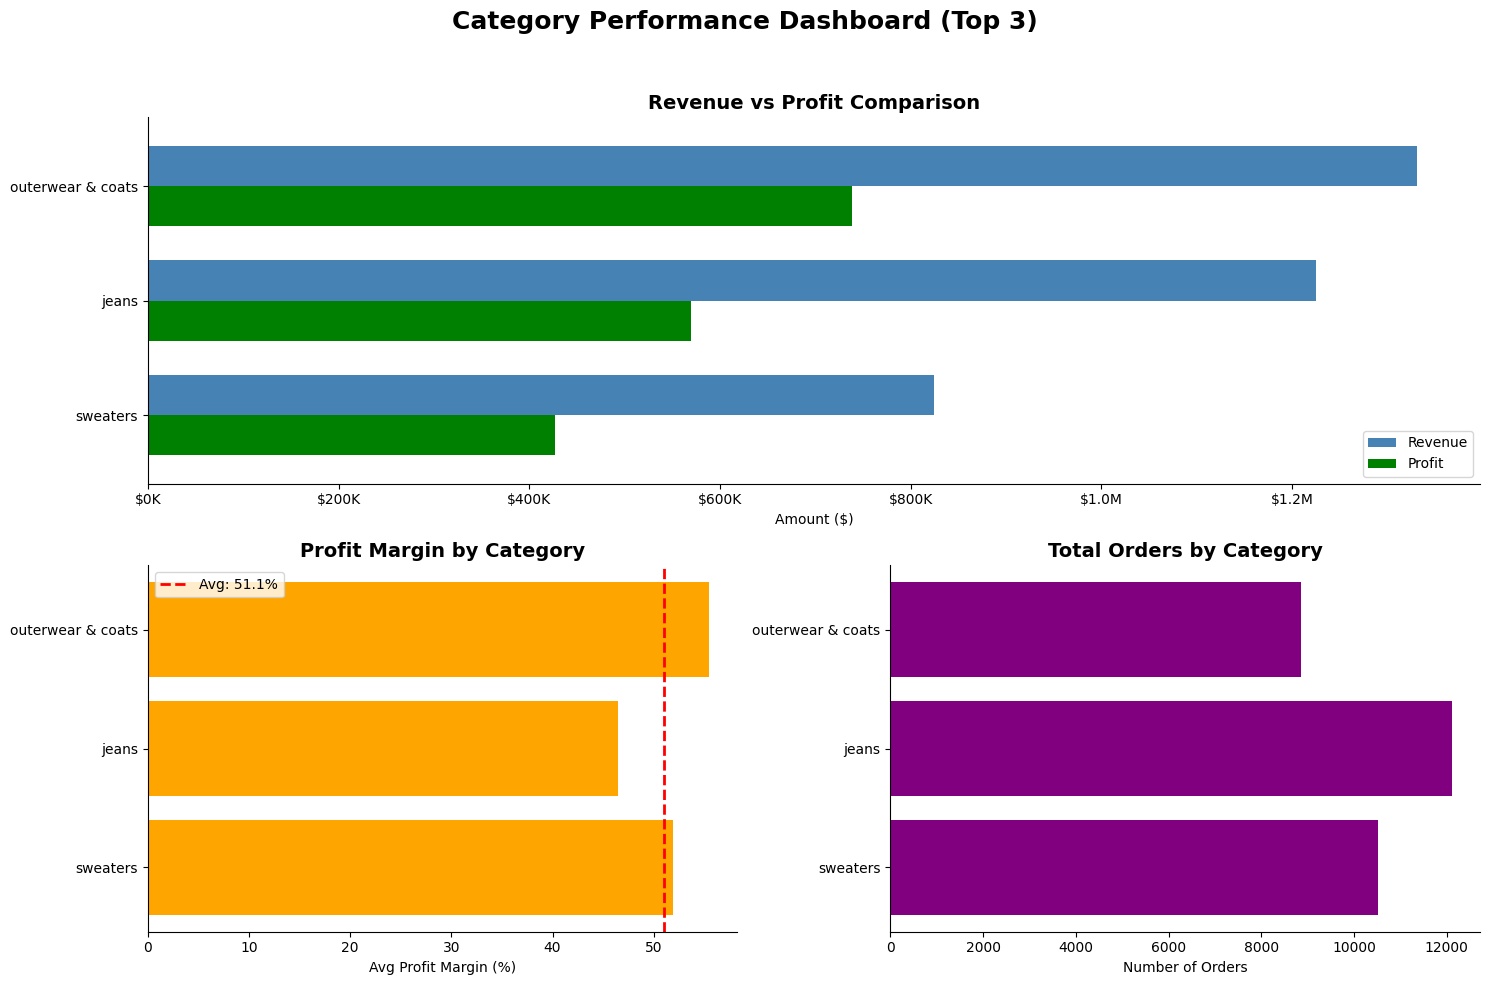

In [32]:
# --- 6. CATEGORY ANALYSIS ---

# Aggregate metrics by category
category_performance = orders_products_df.groupby("category").agg({
    "sale_price": "sum",
    "cost": "sum",
    "profit": "sum",
    "profit_margin": "mean",
    "order_id": "nunique",
    "product_id": "nunique"
}).rename(columns={
    "sale_price": "total_revenue",
    "cost": "total_cost",
    "profit": "total_profit",
    "profit_margin": "avg_margin",
    "order_id": "total_orders",
    "product_id": "unique_products"
}).sort_values("total_revenue", ascending=False)

# Top 3 for visualization
top_3_categories = category_performance.head(3)


# --- CREATING THE DASHBOARD ---

fig = plt.figure(figsize=(15, 10))
fig.suptitle("Category Performance Dashboard (Top 3)", fontsize=18, fontweight="bold", y=0.98)

# REVENUE VS PROFIT 
ax1 = plt.subplot(2, 2, (1, 2)) # Spans row 1, columns 1 and 2

top_3_categories[["total_revenue", "total_profit"]].plot(
    kind="barh", 
    ax=ax1, 
    color=["steelblue", "green"],
    width=0.7)

ax1.set_title("Revenue vs Profit Comparison", fontsize=14, fontweight="bold")
ax1.set_xlabel("Amount ($)")
ax1.set_ylabel("") 
ax1.invert_yaxis() # Puts the #1 category at the top
ax1.legend(["Revenue", "Profit"], loc="lower right")

# Format X axis to show Millions (M) or Thousands (K)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


# 2. PROFIT MARGIN (Bottom Left)
ax2 = plt.subplot(2, 2, 3)
ax2.barh(top_3_categories.index, top_3_categories["avg_margin"], color="orange")
ax2.axvline(avg_profit_margin, color="red", linestyle="--", linewidth=2, label=f"Avg: {avg_profit_margin:.1f}%")

ax2.set_title("Profit Margin by Category", fontsize=14, fontweight="bold")
ax2.set_xlabel("Avg Profit Margin (%)")
ax2.legend()
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# 3. TOTAL ORDERS (Bottom Right)
ax3 = plt.subplot(2, 2, 4)
ax3.barh(top_3_categories.index, top_3_categories["total_orders"], color="purple")

ax3.set_title("Total Orders by Category", fontsize=14, fontweight="bold")
ax3.set_xlabel("Number of Orders")
ax3.invert_yaxis()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [33]:
print("--- CATEGORY INSIGHTS ---")
print(f"Total Categories: {orders_products_df['category'].nunique()}")
print(f"Top Category (Revenue): {category_performance.index[0]} - ${category_performance['total_revenue'].iloc[0]:,.0f}")
print(f"Top Category (Profit): {category_performance.sort_values('total_profit', ascending=False).index[0]} - ${category_performance['total_profit'].max():,.0f}")
print(f"Highest Margin Category: {category_performance.sort_values('avg_margin', ascending=False).index[0]} - {category_performance['avg_margin'].max():.1f}%")
print(f"Lowest Margin Category: {category_performance.sort_values('avg_margin', ascending=True).index[0]} - {category_performance['avg_margin'].min():.1f}%")


--- CATEGORY INSIGHTS ---
Total Categories: 26
Top Category (Revenue): outerwear & coats - $1,330,541
Top Category (Profit): outerwear & coats - $738,945
Highest Margin Category: blazers & jackets - 61.9%
Lowest Margin Category: clothing sets - 38.4%


In [34]:
# --- 7. BRAND ANALYSIS ---

# Aggregate business metrics by brand
brand_performance = orders_products_df.groupby("brand").agg({
    "sale_price": "sum",
    "cost": "sum",
    "profit": "sum",
    "profit_margin": "mean",
    "order_item_id": "count",
    "order_id": "nunique"
}).rename(columns={
    "sale_price": "total_revenue",
    "cost": "total_cost",
    "profit": "total_profit",
    "profit_margin": "avg_margin",
    "order_item_id": "total_sold",
    "order_id": "total_orders"
}).sort_values("total_profit", ascending=False)

# Define a sales threshold to identify low-volume brands
sales_threshold = brand_performance["total_sold"].median()

# Brand classification logic:
# Good   -> positive profit and acceptable sales volume
# Review -> positive profit but low sales volume
# Bad    -> negative total profit
brand_performance["status"] = "Good"
brand_performance.loc[
    (brand_performance["total_profit"] >= 0) &
    (brand_performance["total_sold"] < sales_threshold),
    "status"
] = "Review"

brand_performance.loc[
    brand_performance["total_profit"] < 0,
    "status"
] = "Bad"

print(f"Sales threshold (median total_sold): {sales_threshold:.0f}")
print(f"Brands with negative profit: {(brand_performance['total_profit'] < 0).sum()}")

Sales threshold (median total_sold): 16
Brands with negative profit: 0


In [35]:
# ---7.1 STRATEGIC BRAND DECISIONS ---

print("--- STRATEGIC BRAND DECISIONS ---")

# Top 3 brands to prioritize
top_3_brands = brand_performance.sort_values("total_profit", ascending=False).head(3)
print("\nTop 3 Brands to Prioritize:")
print(top_3_brands[["total_sold", "total_revenue", "total_cost", "total_profit", "avg_margin"]])

# Brands to review: profitable but with low sales volume
review_brands = brand_performance[brand_performance["status"] == "Review"].sort_values(
    ["total_profit", "total_sold"], ascending=[False, True]
)
print(f"\nBrands to Review: {len(review_brands)}")
print("\nTop 5 Brands to Review:")
print(review_brands[["total_sold", "total_revenue", "total_cost", "total_profit", "avg_margin"]].head(5))

# --- BRAND INSIGHTS SUMMARY ---

status_counts = brand_performance["status"].value_counts()

print("\n--- BRAND INSIGHTS SUMMARY ---")
print(f"Total Brands: {len(brand_performance)}")
print(f"Good Brands: {status_counts.get('Good', 0)}")
print(f"Review Brands: {status_counts.get('Review', 0)}")
print(f"Profit negative Brands: {status_counts.get('Bad', 0)}")
print(f"Top Brand by Profit: {brand_performance.index[0]} - ${brand_performance['total_profit'].iloc[0]:,.0f}")
print(f"Worst Brand by Profit: {brand_performance.index[-1]} - ${brand_performance['total_profit'].iloc[-1]:,.0f}")


--- STRATEGIC BRAND DECISIONS ---

Top 3 Brands to Prioritize:
              total_sold  total_revenue    total_cost   total_profit  \
brand                                                                  
calvin klein        3128  199193.210432  93160.149224  106033.061208   
diesel              1441  193262.319904  96376.294915   96886.024990   
carhartt            2538  174099.208932  81891.940226   92207.268706   

              avg_margin  
brand                     
calvin klein   51.597410  
diesel         49.846842  
carhartt       51.980024  

Brands to Review: 1352

Top 5 Brands to Review:
                 total_sold  total_revenue   total_cost  total_profit  \
brand                                                                   
nobis                    14   11615.000000  5036.340010   6578.659990   
nau                      13    4674.650085  1775.186134   2899.463952   
bergama                   6    4499.939941  1840.475428   2659.464514   
autumn cashmere          15

In [36]:
# --- 8. GENDER ANALYSIS ---

# Aggregate business metrics by gender
gender_analysis = orders_products_df.groupby("gender").agg({
    "sale_price": "sum",
    "cost": "sum",
    "profit": "sum",
    "order_id": "nunique",
    "user_id": "nunique",
    "order_item_id": "count"
}).rename(columns={
    "sale_price": "total_revenue",
    "cost": "total_cost",
    "profit": "total_profit",
    "order_id": "total_orders",
    "user_id": "unique_customers",
    "order_item_id": "total_items_sold"
})

# Create additional KPIs
gender_analysis["avg_order_value"] = gender_analysis["total_revenue"] / gender_analysis["total_orders"]
gender_analysis["revenue_per_customer"] = gender_analysis["total_revenue"] / gender_analysis["unique_customers"]
gender_analysis["orders_per_customer"] = gender_analysis["total_orders"] / gender_analysis["unique_customers"]
gender_analysis["avg_item_price"] = gender_analysis["total_revenue"] / gender_analysis["total_items_sold"]
gender_analysis["items_per_order"] = gender_analysis["total_items_sold"] / gender_analysis["total_orders"]

gender_analysis = gender_analysis.sort_values("total_revenue", ascending=False)

print(gender_analysis)

        total_revenue    total_cost  total_profit  total_orders  \
gender                                                            
m        5.661639e+06  2.727143e+06  2.934496e+06         61946   
f        5.005316e+06  2.402619e+06  2.602697e+06         61495   

        unique_customers  total_items_sold  avg_order_value  \
gender                                                        
m                  39859             89633        91.396363   
f                  39371             89376        81.393863   

        revenue_per_customer  orders_per_customer  avg_item_price  \
gender                                                              
m                 142.041674             1.554128       63.164673   
f                 127.132042             1.561936       56.002905   

        items_per_order  
gender                   
m              1.446954  
f              1.453386  


In [ ]:
# 8.1. DATA SELECTION  (USERS + ORDERS_PRODUCTS)
query_users = {
    "orders_products_users": """
    SELECT
        o.order_id,
        o.user_id,
        o.status AS order_status,
        o.created_at AS order_created_at,
        o.shipped_at AS order_shipped_at,
        o.num_of_item,

        oi.id AS order_item_id,
        oi.sale_price,
        oi.status AS item_status,

        p.id AS product_id,
        p.name AS product_name,
        p.category,
        p.brand,
        p.cost,
        p.retail_price,
        p.department,
        p.distribution_center_id,

        u.age,
        u.gender AS user_gender,
        u.country,
        u.city,
        u.state,
        u.traffic_source

    FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
        ON oi.order_id = o.order_id
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
        ON oi.product_id = p.id
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
        ON o.user_id = u.id
    WHERE o.created_at <= CURRENT_TIMESTAMP()
      AND (o.shipped_at <= CURRENT_TIMESTAMP() OR o.shipped_at IS NULL)
    """
}

try:
    orders_products_users_df = client.query(query_users["orders_products_users"]).to_dataframe()
    print(orders_products_users_df.info())
except Exception as e:
    print(f"Something went wrong: {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179009 entries, 0 to 179008
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   order_id                179009 non-null  Int64              
 1   user_id                 179009 non-null  Int64              
 2   order_status            179009 non-null  object             
 3   order_created_at        179009 non-null  datetime64[us, UTC]
 4   order_shipped_at        115788 non-null  datetime64[us, UTC]
 5   num_of_item             179009 non-null  Int64              
 6   order_item_id           179009 non-null  Int64              
 7   sale_price              179009 non-null  float64            
 8   item_status             179009 non-null  object             
 9   product_id              179009 non-null  Int64              
 10  product_name            178996 non-null  object             
 11  category                17

In [38]:
# --- AGE DATA QUALITY CHECK ---

print("--- AGE DATA QUALITY CHECK ---")
print(f"Total rows: {len(orders_products_users_df)}")
print(f"Unique users: {orders_products_users_df['user_id'].nunique()}")
print(f"Missing age values: {orders_products_users_df['age'].isna().sum()}")
print(f"Unique age values: {orders_products_users_df['age'].nunique()}")
print(f"Unique gender values: {orders_products_users_df['user_gender'].nunique()}")
print(f"Minimum age: {orders_products_users_df['age'].min()}")
print(f"Maximum age: {orders_products_users_df['age'].max()}")

--- AGE DATA QUALITY CHECK ---
Total rows: 179009
Unique users: 79230
Missing age values: 0
Unique age values: 59
Unique gender values: 2
Minimum age: 12
Maximum age: 70


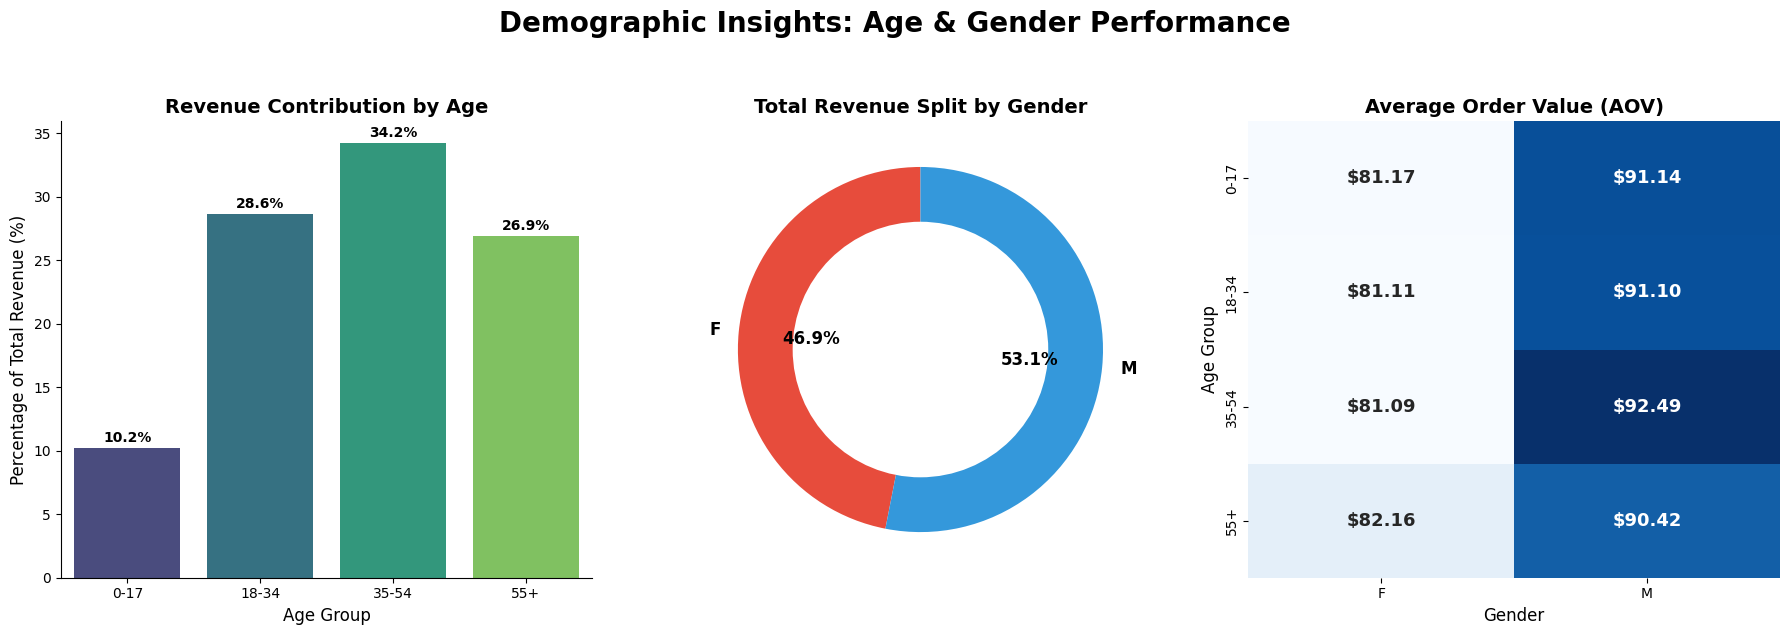

--- KEY INSIGHTS ---
1. THE CORE DEMOGRAPHIC: The 35-54 age group is the backbone of the business, driving nearly 34% of total revenue.
2. REVENUE BALANCE: Revenue is fairly balanced between genders, with Men (M) holding a slight edge at 53%.
3. THE HIDDEN PATTERN (AOV): Age does not significantly impact how much a user spends per order. However, Gender is a massive driver: Men consistently spend ~\$10 more per order than Women, regardless of their age group.


In [ ]:
# --- 8.2 DEMOGRAPHIC ANALYSIS (AGE & GENDER) ---

# Create Custom Age Groups
orders_products_users_df["age_group"] = pd.cut(
    orders_products_users_df["age"],
    bins=[-0.1, 17, 34, 54, 200],
    labels=["0-17", "18-34", "35-54", "55+"],
    include_lowest=True
)

# Filter valid demographic data
demo_df = orders_products_users_df.dropna(subset=["age_group", "user_gender"]).copy()

# 3) Calculate % Share of Revenue and % Share of Customers by Age
age_summary = demo_df.groupby("age_group", observed=False).agg(
    revenue=("sale_price", "sum"),
    customers=("user_id", "nunique")
).reset_index()

total_rev = age_summary["revenue"].sum()
total_cust = age_summary["customers"].sum()

age_summary["revenue_pct"] = (age_summary["revenue"] / total_rev) * 100
age_summary["customers_pct"] = (age_summary["customers"] / total_cust) * 100

# 4) Calculate Average Order Value (AOV) by age and gender
age_gender_agg = demo_df.groupby(["age_group", "user_gender"], observed=False).agg(
    revenue=("sale_price", "sum"),
    orders=("order_id", "nunique")
)
age_gender_agg["AOV"] = age_gender_agg["revenue"] / age_gender_agg["orders"]

# Pivot table for the heatmap (rows: Age, columns: Gender, Values: AOV)
aov_pivot = age_gender_agg["AOV"].unstack()


# --- PLOTTING DASHBOARD ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Demographic Insights: Age & Gender Performance", fontsize=20, fontweight="bold", y=1.05)

# CHART 1: Revenue Contribution by Age (Single, elegant bar chart)
sns.barplot(
    x="age_group", 
    y="revenue_pct", 
    data=age_summary, 
    ax=axes[0], 
    palette="viridis",
    hue="age_group",  
    legend=False       
)
axes[0].set_title("Revenue Contribution by Age", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Percentage of Total Revenue (%)", fontsize=12)
axes[0].set_xlabel("Age Group", fontsize=12)

# Add percentage labels on top of bars
for i in range(len(age_summary)):
    axes[0].text(i, age_summary["revenue_pct"].iloc[i] + 0.5, f"{age_summary['revenue_pct'].iloc[i]:.1f}%", ha='center', fontweight='bold')
    
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# CHART 2: Revenue Split by Gender (Donut Chart)
gender_rev = demo_df.groupby("user_gender")["sale_price"].sum()
axes[1].pie(gender_rev, labels=gender_rev.index, autopct='%1.1f%%', startangle=90, colors=["#e74c3c", "#3498db"], textprops={'fontsize': 12, 'weight': 'bold'})
centre_circle = plt.Circle((0,0),0.70,fc='white')
axes[1].add_patch(centre_circle)
axes[1].set_title("Total Revenue Split by Gender", fontsize=14, fontweight="bold")

# CHART 3: Average Order Value (AOV) by Age & Gender (Heatmap)
sns.heatmap(
    aov_pivot, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    cbar=False, 
    ax=axes[2],
    annot_kws={"size": 13, "weight": "bold"}
)
# Format annotations to include the "$" sign
for t in axes[2].texts:
    t.set_text("$" + t.get_text())

axes[2].set_title("Average Order Value (AOV)", fontsize=14, fontweight="bold")
axes[2].set_ylabel("Age Group", fontsize=12)
axes[2].set_xlabel("Gender", fontsize=12)

plt.tight_layout()
plt.show()

# --- TEXT INSIGHTS ---
print("--- KEY INSIGHTS ---")
print("1. THE CORE DEMOGRAPHIC: The 35-54 age group is the backbone of the business, driving nearly 34% of total revenue.")
print("2. REVENUE BALANCE: Revenue is fairly balanced between genders, with Men (M) holding a slight edge at 53%.")
print("3. THE HIDDEN PATTERN (AOV): Age does not significantly impact how much a user spends per order. However, Gender is a massive driver: Men consistently spend ~\$10 more per order than Women, regardless of their age group.")

In [47]:
# --- 8.3 HYPOTHESIS TESTING: T-TEST ON GENDER AOV ---

# 1) Prepare Data
orders = demo_df.groupby(["order_id", "user_gender"], observed=False)["sale_price"].sum().reset_index()
m_aov = orders[orders["user_gender"] == "M"]["sale_price"]
f_aov = orders[orders["user_gender"] == "F"]["sale_price"]

# 2) Perform Welch's T-Test
t_stat, p_val = stats.ttest_ind(m_aov, f_aov, equal_var=False)

print(f"--- T-TEST RESULTS (AOV: M vs F) ---")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: Statistically SIGNIFICANT. Tailor gender-based marketing strategies.")
else:
    print("Conclusion: NOT SIGNIFICANT. Do not build distinct strategies based on gender.")

--- T-TEST RESULTS (AOV: M vs F) ---
P-Value: 1.0980e-78
Conclusion: Statistically SIGNIFICANT. Tailor gender-based marketing strategies.


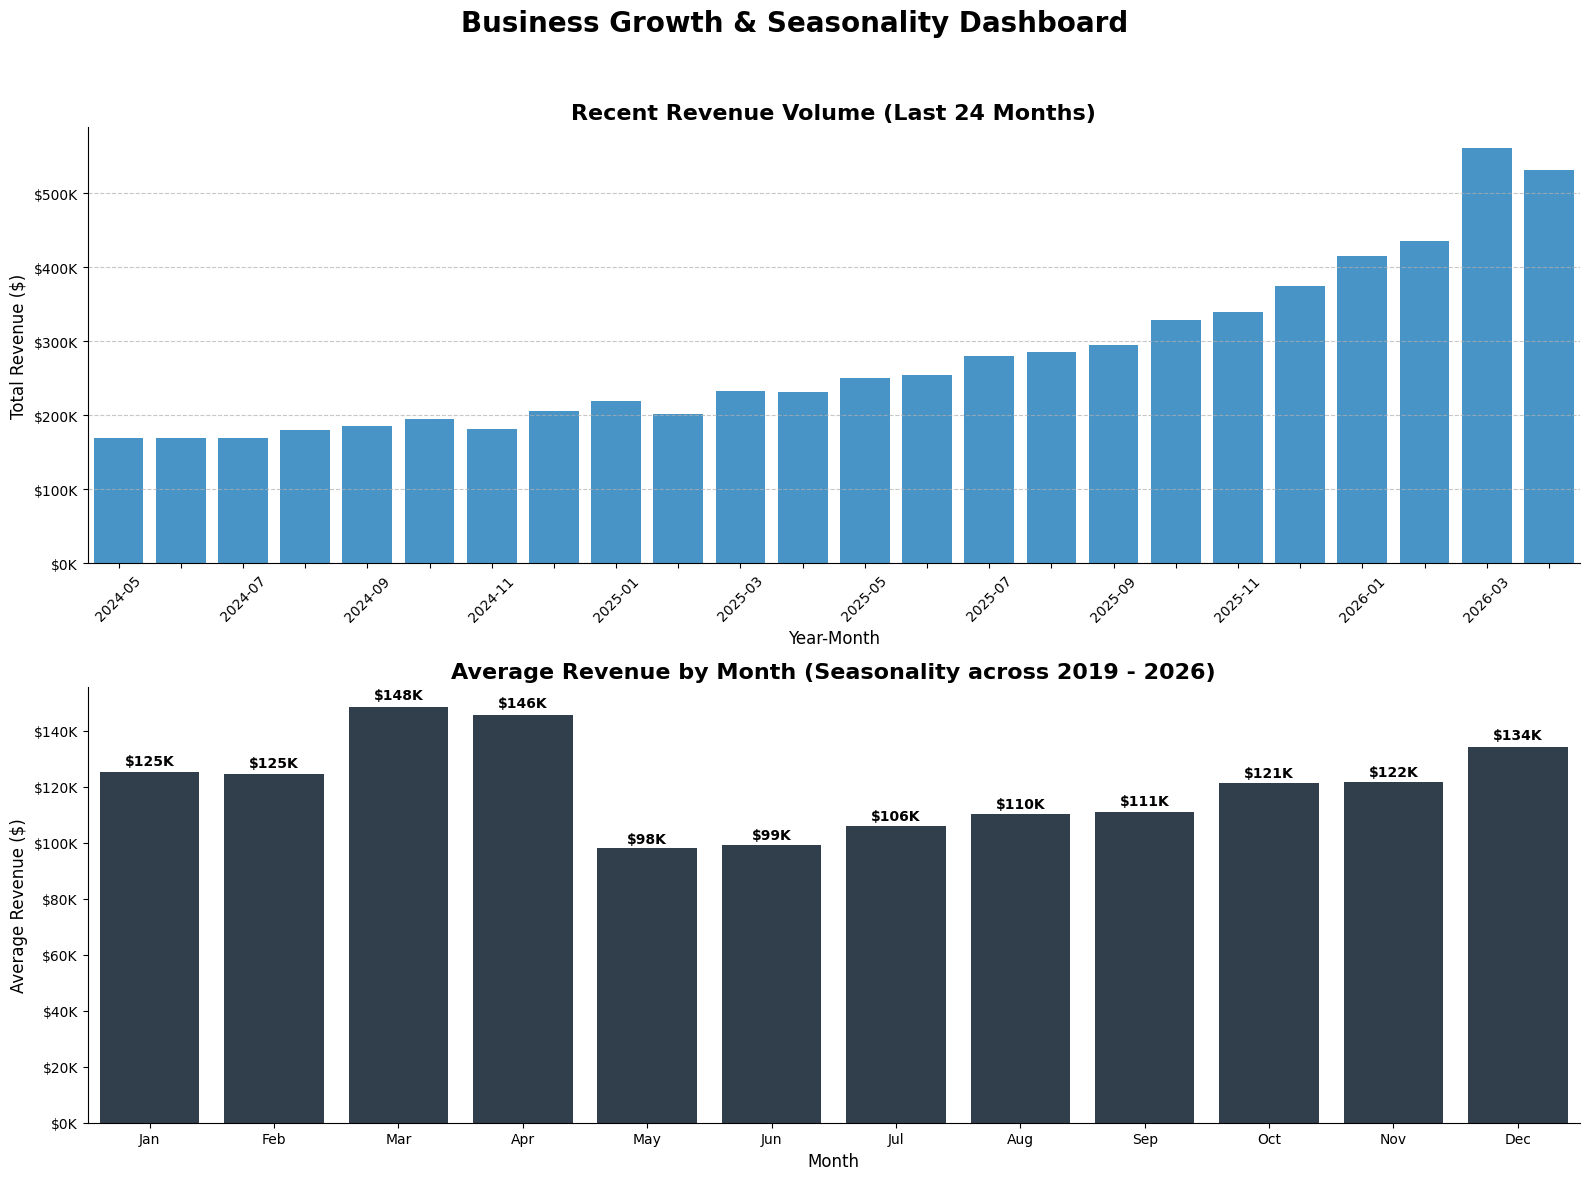

--- TIME SERIES BUSINESS INSIGHTS ---
Peak Recent Volume: 2026-03 reached $561,328.76 in revenue.
 Strongest Season: Mar is historically the strongest month based on 2019-2026 data.
 Weakest Season: May is historically the slowest month.

Actionable Insight: Use the seasonality chart to plan inventory and marketing budgets. Allocate higher ad spend leading up to the strongest months.


In [50]:
# --- 9. TIME SERIES & TREND ANALYSIS (LAST 24 MONTHS) ---

# Extract Year, Month, Month Name, and Year-Month combination
orders_products_df['year'] = orders_products_df['order_created_at'].dt.year
orders_products_df['month'] = orders_products_df['order_created_at'].dt.month
orders_products_df['month_name'] = orders_products_df['order_created_at'].dt.strftime('%b')
orders_products_df['year_month'] = orders_products_df['order_created_at'].dt.strftime('%Y-%m')

# Total revenue for every single month
trend_df = orders_products_df.groupby('year_month').agg(
    revenue=('sale_price', 'sum')
).reset_index()

# Zoom in on the last 24 months to see the actual month-over-month variations
# (The dataset has an exponential startup growth that flattens older visual data)
recent_trend_df = trend_df.tail(24)

min_year = orders_products_df['year'].min()
max_year = orders_products_df['year'].max()

# Totals for each specific month-year
monthly_totals = orders_products_df.groupby(['year', 'month', 'month_name']).agg(
    revenue=('sale_price', 'sum')
).reset_index()

seasonality_df = monthly_totals.groupby(['month', 'month_name']).agg(
    avg_revenue=('revenue', 'mean')
).reset_index().sort_values('month')


# --- PLOTTING THE DASHBOARD ---

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle("Business Growth & Seasonality Dashboard", fontsize=20, fontweight="bold", y=0.98)

# CHART 1: Historical Trend (Last 24 Months)
sns.barplot(
    x='year_month', 
    y='revenue', 
    data=recent_trend_df, 
    ax=axes[0], 
    color="#3498db")

axes[0].set_title("Recent Revenue Volume (Last 24 Months)", fontsize=16, fontweight="bold")
axes[0].set_ylabel("Total Revenue ($)", fontsize=12)
axes[0].set_xlabel("Year-Month", fontsize=12)

# To prevent text overlapping
for ind, label in enumerate(axes[0].get_xticklabels()):
    if ind % 2 == 0:
        label.set_visible(True)
    else:
        label.set_visible(False)
axes[0].tick_params(axis='x', rotation=45)

# Format Y-axis as Millions (M) or Thousands (K)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# CHART 2: Average Revenue by Month (Seasonality)
sns.barplot(
    x='month_name', 
    y='avg_revenue', 
    data=seasonality_df, 
    ax=axes[1], 
    color="#2c3e50" 
)

axes[1].set_title(f"Average Revenue by Month (Seasonality across {min_year} - {max_year})", fontsize=16, fontweight="bold")
axes[1].set_ylabel("Average Revenue ($)", fontsize=12)
axes[1].set_xlabel("Month", fontsize=12)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Add the exact dollar values on top of the bars
for i in range(len(seasonality_df)):
    val = seasonality_df['avg_revenue'].iloc[i]
    axes[1].text(i, val + (val*0.02), f"${val/1e3:.0f}K", ha='center', fontweight='bold', fontsize=10)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- TEXT INSIGHTS ---

print("--- TIME SERIES BUSINESS INSIGHTS ---")

# Find the best month in the recent 24-month dataset
best_recent_month = recent_trend_df.loc[recent_trend_df['revenue'].idxmax()]
print(f"Peak Recent Volume: {best_recent_month['year_month']} reached ${best_recent_month['revenue']:,.2f} in revenue.")

# Identify seasonal highs and lows
best_seasonal_month = seasonality_df.loc[seasonality_df['avg_revenue'].idxmax()]
worst_seasonal_month = seasonality_df.loc[seasonality_df['avg_revenue'].idxmin()]

print(f" Strongest Season: {best_seasonal_month['month_name']} is historically the strongest month based on {min_year}-{max_year} data.")
print(f" Weakest Season: {worst_seasonal_month['month_name']} is historically the slowest month.")
print("\nActionable Insight: Use the seasonality chart to plan inventory and marketing budgets. Allocate higher ad spend leading up to the strongest months.")

### Final Analyst Note: Understanding the Exponential Growth
Throughout the time series analysis, you may have noticed an aggressive, continuous exponential growth in sales volume over the years (growing from a few thousand dollars to millions). 

It is important to highlight that *TheLook eCommerce* is a **synthetic dataset** generated by Google Cloud. 

In real-world e-commerce, businesses usually experience periods of plateau, and year-over-year growth eventually stabilizes. Synthetic datasets, however, are often programmed with constant, exponential upward curves to simulate massive scaling scenarios and stress-test database performance.

Therefore, while the massive total volume of the later years is artificially inflated by the algorithm, the **seasonality patterns (month-over-month behavior)**, **demographic insights**, and **brand performance metrics** we extracted remain mathematically valid and highly relevant for demonstrating advanced business analytics techniques.